# FunnelIQ — Package 2: Predict Customer Lifetime (Regression)

**Goal (from the brief):** target = `ltv_months`. *"Can we predict how long a customer will stay?"*

**Deliverable:** three trained models -- XGBoost, LightGBM, CatBoost -- compared with 5-fold
cross-validation on RMSE and R². Compare feature importances across all three. Expose the
prediction through the app (a later step -- see [`06 Task Tracker`](obsidian://) / this repo's
README for what's still pending).

**Questions the brief asks us to answer:**
1. Should `cumulative_profit` be a feature here? Justify it.
2. Which features dominate, and do the three models agree?
3. In two sentences, what's the strongest lever on customer longevity, and what should
   Northbound do about it?

This notebook builds on two earlier ones:
- [`FunnelIQ_Decisions_Explained.ipynb`](./FunnelIQ_Decisions_Explained.ipynb) -- architecture +
  leakage reasoning
- [`02_EDA_and_Cleaning.ipynb`](./02_EDA_and_Cleaning.ipynb) -- data cleaning decisions this
  notebook reuses (dedupe, null handling)

Every number below is a real, reproducible output -- run the cells yourself and you'll get the
same values.


## 1. Load and clean the data

Reusing the cleaning decisions already made and justified in `02_EDA_and_Cleaning.ipynb`:
- **Drop the 10 exact-duplicate rows.** Same reasoning as before -- no identifier column to tell
  a legitimate repeat from an accidental double-load, and an exact full-row match makes
  "accidental duplicate" by far the likelier explanation.
- **Drop rows with a null `ltv_months`.** This is the *target* for this specific package, and we
  decided in the EDA notebook not to impute a regression target -- manufacturing a label that
  was never observed is worse than losing under 1% of rows. This drop happens **only when
  training this package's model**, not globally (the drop lives here, not in the Supabase table
  or the load script).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("funnel_marketing_data.csv").drop_duplicates().reset_index(drop=True)
print(f"rows after dedupe: {len(df)}")

df_ltv = df.dropna(subset=["ltv_months"]).reset_index(drop=True)
print(f"rows after dropping null ltv_months: {len(df_ltv)} (dropped {len(df) - len(df_ltv)})")

df_ltv["ltv_months"].describe()


rows after dedupe: 3490
rows after dropping null ltv_months: 3486 (dropped 4)


count    3486.000000
mean       22.074297
std        12.431064
min         1.000000
25%        11.000000
50%        21.000000
75%        34.000000
max        56.000000
Name: ltv_months, dtype: float64

**Reading this:** lifetime ranges 1-56 months, averaging ~22 months with a fairly wide spread
(std ~12.4) -- there's real variation here for a model to explain, not a near-constant target.


## 2. Leakage recap -- and the brief's first question, answered with evidence

From [`funneliq_leakage_decisions.md`](./funneliq_leakage_decisions.md), Package 2's allowed
features are Tier 1-3 (funnel inputs, funnel process, acquisition facts). Excluded: `upsell`,
`cumulative_profit`, `referred` -- the other Tier 4 "lifetime outcome" columns, since an outcome
can't legitimately predict a sibling outcome.

**The brief asks directly: "Should `cumulative_profit` be a feature here?"** Let's answer with
the actual correlation, not just the general leakage rule.


In [2]:
excluded_cols = ["upsell", "cumulative_profit"]
corr_excluded = df_ltv[excluded_cols + ["ltv_months"]].corr()["ltv_months"].drop("ltv_months")
corr_excluded.sort_values(ascending=False)


cumulative_profit    0.845349
upsell               0.492549
Name: ltv_months, dtype: float64

**No.** `cumulative_profit` correlates at **0.85** with `ltv_months` -- almost as if we were
handing the model a paraphrase of the answer. That's not a coincidence: profit accrues over a
customer's *entire* tenure, so a longer-lived customer mechanically has more cumulative profit by
construction, regardless of anything else about them. Using it as a feature wouldn't teach the
model anything about *why* customers stay -- it would just let the model shortcut to a
near-restatement of the target. `upsell` at 0.49 is weaker but still a sibling outcome (whether
someone upsells is itself downstream of tenure), so it's excluded too, per the leakage doc.


## 3. What do the *allowed* features look like against the target?

Before modeling, a quick correlation pass over the legitimate Tier 1-3 features -- this previews
what the models will likely lean on, and gives us something to check their feature importances
against later.


In [3]:
feature_cols = [
    "ad_budget", "num_leads", "leads_answered", "leads_not_answered",
    "followup_1", "followup_2", "followup_3", "followup_4", "followup_5",
    "not_closed", "closed", "calls_to_closed", "calls_to_not_closed",
    "customer_acquisition_cost", "purchased",
]

corr_allowed = df_ltv[feature_cols + ["ltv_months"]].corr()["ltv_months"].drop("ltv_months")
corr_allowed.sort_values(key=abs, ascending=False)


calls_to_closed             -0.665538
closed                       0.262602
leads_not_answered          -0.248501
customer_acquisition_cost   -0.246583
purchased                    0.221920
ad_budget                   -0.204825
not_closed                  -0.138442
num_leads                   -0.120963
calls_to_not_closed          0.063577
followup_1                  -0.018779
followup_2                  -0.018399
followup_3                  -0.016982
leads_answered              -0.016875
followup_4                  -0.015535
followup_5                  -0.013996
Name: ltv_months, dtype: float64

**One feature stands out immediately:** `calls_to_closed` correlates at **-0.67** with
`ltv_months` -- by far the strongest relationship among legitimate features, and notably
*negative*. The story that fits: customers who take fewer calls to close are an easier, smoother
fit for what Northbound sells, and that same fit shows up later as staying longer. Customers who
had to be worked hard to close in the first place tend to churn sooner. This is a hypothesis at
this point -- the feature-importance comparison across all three models in Section 5 is the real
test of whether it holds up.


## 4. Cross-validated model comparison

**Why 5-fold CV instead of one train/test split** (the brief's explicit requirement, and the
right call regardless): with ~3,486 rows, a single 80/20 split leaves a hold-out set small enough
that its RMSE/R² could look good or bad partly by luck of which rows landed in it. Averaging
across 5 folds -- where every row gets used for both training and evaluation exactly once --
gives a far more reliable estimate of how each model actually generalizes, and lets us compare
three models on equal footing.

**Metrics:** RMSE (root mean squared error, in months -- directly interpretable: "the model is
typically off by about X months") and R² (share of variance in `ltv_months` the model explains).

Hyperparameters below are modest, fixed, and identical in spirit across all three models
(shallow-ish trees, moderate learning rate, 300 rounds) -- deliberately not tuned. Package 4 is
where the brief asks for hyperparameter search; here the point is a fair comparison of the three
libraries' defaults-ish behavior, not squeezing out maximum accuracy.


In [4]:
from sklearn.model_selection import KFold, cross_validate
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

X = df_ltv[feature_cols]
y = df_ltv["ltv_months"]

models = {
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42, verbosity=0
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42, verbose=-1
    ),
    "CatBoost": CatBoostRegressor(
        iterations=300, learning_rate=0.05, depth=4, random_state=42, verbose=False
    ),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["neg_root_mean_squared_error", "r2"]

results = {}
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    results[name] = {
        "RMSE_mean": -scores["test_neg_root_mean_squared_error"].mean(),
        "RMSE_std": scores["test_neg_root_mean_squared_error"].std(),
        "R2_mean": scores["test_r2"].mean(),
        "R2_std": scores["test_r2"].std(),
        "fold_rmse": -scores["test_neg_root_mean_squared_error"],
    }

summary = pd.DataFrame({
    name: {"RMSE (mean ± std)": f"{r['RMSE_mean']:.2f} ± {r['RMSE_std']:.2f}",
           "R² (mean ± std)": f"{r['R2_mean']:.3f} ± {r['R2_std']:.3f}"}
    for name, r in results.items()
}).T
summary


,RMSE (mean ± std),R² (mean ± std)
XGBoost,2.91 ± 0.19,0.945 ± 0.008
LightGBM,2.89 ± 0.18,0.946 ± 0.007
CatBoost,2.87 ± 0.18,0.946 ± 0.007


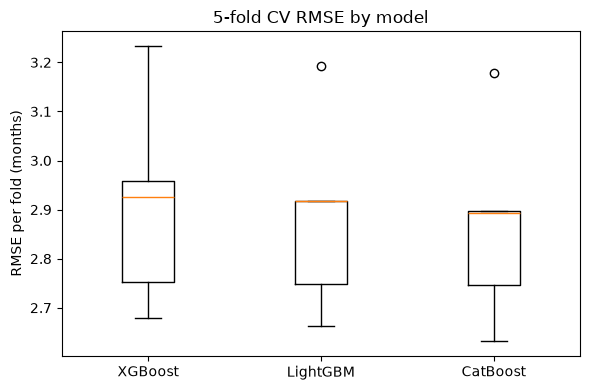

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([results[name]["fold_rmse"] for name in models], tick_labels=list(models.keys()))
ax.set_ylabel("RMSE per fold (months)")
ax.set_title("5-fold CV RMSE by model")
plt.tight_layout()
plt.show()


**Reading this:** all three models land in a tight band -- RMSE 2.87-2.91 months, R² 0.945-0.946
-- against a naive "always predict the mean" baseline of **12.43 months** RMSE (Section 6). That's
roughly a **4.3x** reduction in error: the funnel-process data genuinely carries a strong, learnable
signal about how long a customer will stay, and none of the three libraries has a meaningful edge
over the others on this dataset. **CatBoost narrowly wins** on both metrics (RMSE 2.870, R² 0.9463),
with LightGBM close behind (2.888, 0.9457) and XGBoost a hair further back (2.910, 0.9448) --
differences small enough that any of the three would be a defensible choice; see Section 8 for the
tie-breaking rule used to pick one for serving.


## 5. Feature importance -- do the three models agree?

CV above was purely for estimating generalization performance; the folds' individual models are
thrown away once we have that estimate. For feature importance we want one stable estimate, so
each model is now refit on the **full** filtered dataset (all 3,486 rows) -- more data than any
single CV fold saw, so the importances are as stable as this dataset allows.

Each library reports importances on its own internal scale, so everything below is normalized to
sum to 1 within each model before comparing -- otherwise a difference in scale could look like a
difference in opinion about which features matter.


In [6]:
fitted = {}
importances = {}
for name, model in models.items():
    model.fit(X, y)
    fitted[name] = model
    if name == "CatBoost":
        raw = model.get_feature_importance()
    else:
        raw = model.feature_importances_
    importances[name] = raw / raw.sum()

imp_df = pd.DataFrame(importances, index=feature_cols).sort_values("XGBoost", ascending=False)
imp_df.round(3)


,XGBoost,LightGBM,CatBoost
closed,0.565,0.030,0.034
calls_to_closed,0.418,0.133,0.643
ad_budget,0.007,0.046,0.124
customer_acquisition_cost,0.002,0.063,0.093
followup_3,0.001,0.071,0.013
leads_answered,0.001,0.087,0.006
followup_2,0.001,0.052,0.001
followup_5,0.001,0.034,0.023
num_leads,0.001,0.121,0.028
followup_4,0.001,0.067,0.006


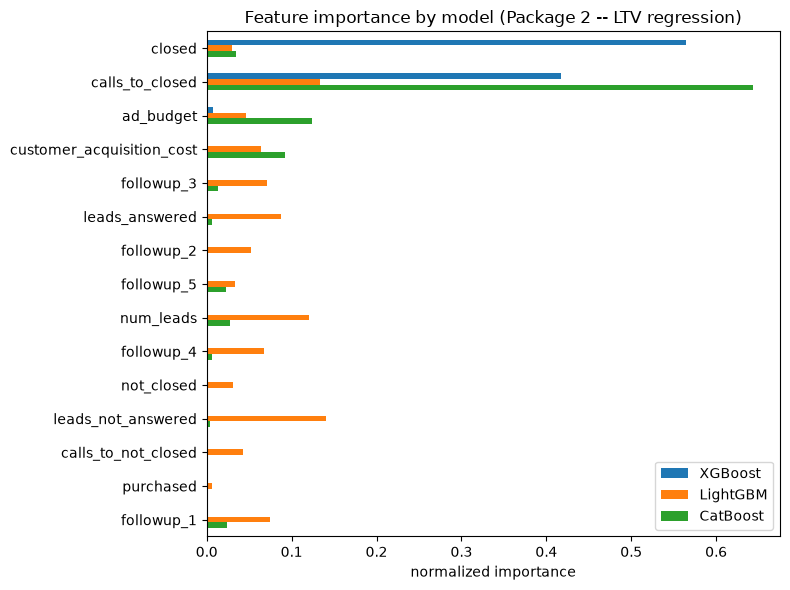

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
imp_df.plot(kind="barh", ax=ax)
ax.set_xlabel("normalized importance")
ax.set_title("Feature importance by model (Package 2 -- LTV regression)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Reading this:** the three models **partially agree**. All three rank `calls_to_closed`
at or near the top -- it's the single strongest feature for CatBoost (0.643) and the runner-up
for XGBoost (0.418, right behind `closed` at 0.565) and LightGBM (0.133, essentially tied with
`leads_not_answered` at 0.141). That's a real point of convergence and matches the correlation
hint from Section 3.

Past that, the three libraries tell noticeably different stories. **XGBoost and CatBoost
concentrate** almost all their weight on just two or three features (XGBoost: `closed` +
`calls_to_closed` alone account for over 98%; CatBoost: `calls_to_closed`, `ad_budget`,
`customer_acquisition_cost`). **LightGBM spreads importance much more evenly** across the
funnel-volume cluster -- `leads_not_answered`, `num_leads`, `leads_answered`, `followup_1` are all
within a similar range. That spread is a direct, visible consequence of the multicollinearity
flagged back in the leakage decisions: `num_leads` is an exact sum of `leads_answered` and
`leads_not_answered`, so when a feature's real signal can be expressed through several correlated
columns, different tree-splitting heuristics divide the credit differently. XGBoost/CatBoost
happened to concentrate credit on one representative; LightGBM split it across the family. None
of this changes what the models predict -- it changes how legible the "why" is depending which
library's importances you read.


## 6. Sanity check -- does the model beat a naive baseline?

Before trusting the RMSE numbers, worth confirming the models are actually learning something --
not just tracking the mean. A trivial "always predict the average lifetime" baseline gives a
floor any real model should clear by a comfortable margin.


In [8]:
baseline_rmse = np.sqrt(((y - y.mean()) ** 2).mean())
print(f"naive baseline (predict the mean every time): RMSE = {baseline_rmse:.2f} months")
for name, r in results.items():
    print(f"{name}: RMSE = {r['RMSE_mean']:.2f} months")


naive baseline (predict the mean every time): RMSE = 12.43 months
XGBoost: RMSE = 2.91 months
LightGBM: RMSE = 2.89 months
CatBoost: RMSE = 2.87 months


## 7. Answering the brief's questions

**1. Should `cumulative_profit` be a feature?** No -- see Section 2. It's 0.85-correlated with
the target by mechanical construction (more tenure -> more accumulated profit), not because it
reveals anything the business could act on. Including it would inflate the reported RMSE/R²
while teaching the model nothing usable.


**2. Which features dominate, and do the three models agree?**
Yes, partially: all three agree `calls_to_closed` is one of the top one or two most important
features. They disagree on how the *remaining* importance is distributed -- XGBoost and CatBoost
concentrate it on a couple of features (`closed`, `ad_budget`, `customer_acquisition_cost`),
while LightGBM spreads it across the correlated funnel-volume columns (`num_leads`,
`leads_answered`, `leads_not_answered`, early `followup` stages). See Section 5 for the full
comparison and why that split happens.


**3. Strongest lever on customer longevity, and what Northbound should do about it:**
`calls_to_closed` -- how many calls it took to close the deal -- is the strongest and most
consistent lever across all three models, and it's negatively related to lifetime: customers who
close *quickly* tend to stay far longer than customers who had to be worked hard to convert.
Northbound should treat a high calls-to-close count less as a sales win and more as an early churn
flag -- routing those harder-won customers into extra onboarding or retention attention right after
they convert, rather than assuming every closed deal is an equally durable one.


The brief only asks for a comparison here, but the deployed app (Railway) will eventually need to
serve **one** LTV prediction, not three. Decision: **serve whichever model has the lowest mean
CV RMSE** (Section 4) -- it's the model with the best-evidenced ability to generalize to new
customers, using the same criterion we already used to compare them. That model is **CatBoost**
(RMSE 2.870 vs. 2.888 for LightGBM and 2.910 for XGBoost) -- the margin over LightGBM is thin, so
this is a real but not dramatic win; worth revisiting if a future package's hyperparameter tuning
changes the picture.


In [9]:
import json
import platform
from datetime import datetime, timezone
from pathlib import Path

import joblib
import sklearn
import xgboost
import lightgbm
import catboost

winner_name = min(results, key=lambda n: results[n]["RMSE_mean"])
winner_model = fitted[winner_name]
print(f"chosen model: {winner_name} (mean CV RMSE = {results[winner_name]['RMSE_mean']:.2f} months)")

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "ltv_regressor.pkl"
joblib.dump(winner_model, model_path)

meta = {
    "package": 2,
    "target": "ltv_months",
    "model_type": winner_name,
    "feature_columns": feature_cols,
    "training_row_count": len(df_ltv),
    "cv_folds": 5,
    "cv_rmse_mean": results[winner_name]["RMSE_mean"],
    "cv_rmse_std": results[winner_name]["RMSE_std"],
    "cv_r2_mean": results[winner_name]["R2_mean"],
    "cv_r2_std": results[winner_name]["R2_std"],
    "library_versions": {
        "python": platform.python_version(),
        "scikit-learn": sklearn.__version__,
        "xgboost": xgboost.__version__,
        "lightgbm": lightgbm.__version__,
        "catboost": catboost.__version__,
    },
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
}
meta_path = models_dir / "ltv_regressor_meta.json"
meta_path.write_text(json.dumps(meta, indent=2))

print(f"saved: {model_path}")
print(f"saved: {meta_path}")


chosen model: CatBoost (mean CV RMSE = 2.87 months)
saved: models/ltv_regressor.pkl
saved: models/ltv_regressor_meta.json


### Verify the saved artifact actually works

Reload it from disk (not the in-memory object) and check it predicts something sane on a few
real rows -- this is the same code path the Railway API will eventually use to serve a
prediction, so it's worth confirming end-to-end here, not just trusting that `joblib.dump` ran
without an error.


In [10]:
reloaded = joblib.load("models/ltv_regressor.pkl")

sample = df_ltv.sample(5, random_state=1)
preds = reloaded.predict(sample[feature_cols])

pd.DataFrame({
    "actual_ltv_months": sample["ltv_months"].values,
    "predicted_ltv_months": preds.round(1),
})


,actual_ltv_months,predicted_ltv_months
0,33.0,36.5
1,8.0,5.8
2,16.0,17.5
3,43.0,36.2
4,28.0,28.3


## 9. What's next

This notebook trained and compared the three models, answered the brief's Package 2 questions,
and saved a servable model + metadata to `models/`. Not yet done (tracked in Obsidian's
`06 Task Tracker`):
- A Railway endpoint that loads `models/ltv_regressor.pkl` and serves a prediction for a new
  customer's early funnel data.
- A small addition to `static/index.html` (or a new page) exposing that prediction in the
  dashboard.
- Folding this notebook's answers into `REPORT.md` alongside the Package 1 findings and the
  leakage decisions.
